# Which celebrity do you look like?

Give it a photo of a face and it returns the identities (cricketers, footballers, actors)
whose faces are most similar, using the shared `faceutil` module (YuNet detect + align,
SFace embedding) and the gallery built by `face_recognition_pipeline.py`.

Matching is cosine similarity of the face embedding to each identity's mean embedding.
Run `prepare_dataset.py` then `face_recognition_pipeline.py` first.

In [ ]:
import os
import pickle
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import faceutil

IMG_EXT = ('.jpg', '.jpeg', '.png', '.webp', '.gif')
GALLERY = 'celebrity'

with open('face_recognizer.pkl', 'rb') as f:
    R = pickle.load(f)
labels, centroids = R['labels'], R['centroids']
print(len(labels), 'identities in the gallery')

In [2]:
def pretty(name):
    return name.replace('_', ' ').title()

def reference_image(player):
    d = os.path.join(GALLERY, player)
    for f in sorted(os.listdir(d)):
        if f.lower().endswith(IMG_EXT):
            return os.path.join(d, f)

def lookalike(img_path, topk=5):
    """Show the query face next to the top-k most similar players."""
    img = cv2.imread(img_path)
    if img is None:
        print('Could not read', img_path); return
    emb, box, _ = faceutil.embed(img)
    if emb is None:
        print('No face detected in', img_path); return

    sims = centroids @ emb
    top = np.argsort(sims)[::-1][:topk]

    fig, axes = plt.subplots(1, topk + 1, figsize=(2.4 * (topk + 1), 2.8))
    q = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x, y, w, h = box
    cv2.rectangle(q, (x, y), (x + w, y + h), (0, 255, 0), 2)
    axes[0].imshow(q); axes[0].set_title('You'); axes[0].axis('off')
    for ax, i in zip(axes[1:], top):
        ref = cv2.cvtColor(cv2.imread(reference_image(labels[i])), cv2.COLOR_BGR2RGB)
        ax.imshow(ref)
        ax.set_title(f'{pretty(labels[i])}\n{sims[i] * 100:.0f}%')
        ax.axis('off')
    plt.tight_layout(); plt.show()

    print('Most similar:')
    for i in top:
        print(f'  {pretty(labels[i]):22s} {sims[i] * 100:5.1f}%')
    return labels[top[0]]

## Try it on your own photo
Point it at a selfie / any face image.

In [3]:
# lookalike('my_selfie.jpg')

## Capture from webcam (optional)
Opens the webcam, press SPACE to capture, ESC to cancel, then matches the shot.

In [4]:
def capture_and_match(cam=0):
    cap = cv2.VideoCapture(cam)
    shot = None
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        cv2.imshow('SPACE = capture, ESC = cancel', frame)
        k = cv2.waitKey(1) & 0xFF
        if k == 27:            # ESC
            break
        if k == 32:            # SPACE
            shot = frame; break
    cap.release(); cv2.destroyAllWindows()
    if shot is not None:
        cv2.imwrite('_selfie.jpg', shot)
        return lookalike('_selfie.jpg')

# capture_and_match()

## Sanity check on a gallery image
Uses a random gallery photo as a stand-in "selfie" (its own player should top the list).

Stand-in selfie is actually: Dybala


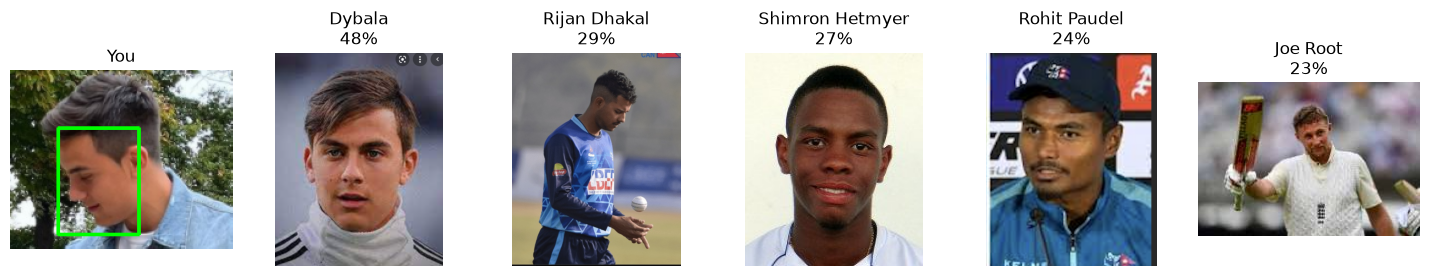

Most similar:
  Dybala                  47.9%
  Rijan Dhakal            29.3%
  Shimron Hetmyer         26.7%
  Rohit Paudel            23.8%
  Joe Root                22.8%


'dybala'

In [5]:
player = random.choice(labels)
folder = os.path.join(GALLERY, player)
img_file = random.choice([f for f in os.listdir(folder) if f.lower().endswith(IMG_EXT)])
print('Stand-in selfie is actually:', pretty(player))
lookalike(os.path.join(folder, img_file))